# Round 1: ML Training with 17 Features

Train 5 classification models:
1. Random Forest
2. Gradient Boosting
3. XGBoost
4. Logistic Regression
5. Support Vector Classifier

Protocol: 85%/15% split, StratifiedShuffleSplit 10-fold CV

In [1]:
import sys
sys.path.insert(0, '..')
import pickle
import numpy as np
import warnings
warnings.filterwarnings('ignore')

with open('../data/preprocessed_round1.pkl', 'rb') as f:
    data = pickle.load(f)

X_train, X_test = data['X_train_s'], data['X_test_s']
y_train, y_test = data['y_train'], data['y_test']
feature_names = data['feature_names']
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (226, 17), Test: (41, 17)


In [2]:
from src.models import get_models, train_and_evaluate

models = get_models()
results_r1 = train_and_evaluate(X_train, X_test, y_train, y_test, models)

print("\n" + "=" * 65)
print(f"{'Model':<25} {'AUC':>8} {'Accuracy':>10}")
print("=" * 65)
for name, res in results_r1.items():
    print(f"{name:<25} {res['auc']:>8.4f} {res['accuracy']:>10.4f}")
print("=" * 65)


Model                          AUC   Accuracy
Random Forest               0.9581     0.8780
Gradient Boosting           0.9516     0.8293
XGBoost                     0.9387     0.8537
Logistic Regression         0.8774     0.8537
SVC                         0.8839     0.8780


In [3]:
# 10-fold CV for Random Forest
from src.models import cross_validate_model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_r1 = cross_validate_model(data['X_train_s'], y_train, rf, n_splits=10)
print(f"Random Forest 10-fold CV (Round 1, 17 features):")
print(f"  AUC:      {cv_r1['auc_mean']:.4f} +/- {cv_r1['auc_std']:.4f}")
print(f"  Accuracy: {cv_r1['acc_mean']:.4f} +/- {cv_r1['acc_std']:.4f}")

Random Forest 10-fold CV (Round 1, 17 features):
  AUC:      0.7486 +/- 0.0772
  Accuracy: 0.8029 +/- 0.0437


Saved: /home/yhm/desktop/code/anion-paper/figures/feature_importance_r1.png


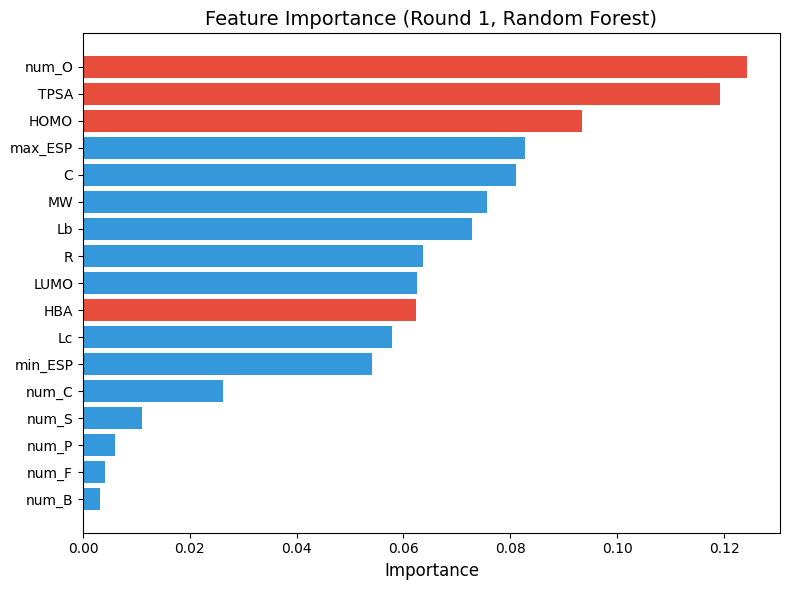


Feature importance ranking:
       num_O: 0.1243
        TPSA: 0.1193
        HOMO: 0.0934
     max_ESP: 0.0827
           C: 0.0812
          MW: 0.0755
          Lb: 0.0728
           R: 0.0636
        LUMO: 0.0626
         HBA: 0.0623
          Lc: 0.0578
     min_ESP: 0.0541
       num_C: 0.0263
       num_S: 0.0110
       num_P: 0.0060
       num_F: 0.0040
       num_B: 0.0031


In [4]:
# Feature importance from Random Forest
from src.models import get_feature_importance
from src.visualization import plot_feature_importance, save_fig
import matplotlib.pyplot as plt

rf_model = results_r1['Random Forest']['model']
importance = get_feature_importance(rf_model, feature_names)
fig = plot_feature_importance(importance, title="Feature Importance (Round 1, Random Forest)")
save_fig(fig, "feature_importance_r1.png")
plt.show()

print("\nFeature importance ranking:")
for feat, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feat:>10}: {imp:.4f}")

In [5]:
# Save round 1 results
with open('../data/results_round1.pkl', 'wb') as f:
    pickle.dump({'results': results_r1, 'feature_names': feature_names, 'cv': cv_r1}, f)
print("Round 1 results saved.")

Round 1 results saved.
